In [1]:
# Import the libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression

In [3]:
# Load the cleaned dataset
df = pd.read_pickle("../data/processed/clean_data.pkl")

In [4]:
# Check the date range
print("Start date:", df["InvoiceDate"].min())
print("End date:", df["InvoiceDate"].max())

Start date: 2009-12-01 07:45:00
End date: 2011-12-09 12:50:00


### Calculate monthly revenue

In [5]:
monthly_revenue = (
    df.groupby("Month")["Revenue"]
    .sum()
    .reset_index()
)

In [6]:
# Check the monthly data
monthly_revenue.head()

,Month,Revenue
0,2009-12,683504.010
1,2010-01,555802.672
2,2010-02,504558.956
3,2010-03,696978.471
4,2010-04,591982.002


In [7]:
monthly_revenue.tail()

,Month,Revenue
20,2011-08,644051.040
21,2011-09,950690.202
22,2011-10,1035642.450
23,2011-11,1156205.610
24,2011-12,517208.440


### Remove incomplete December 2011

In [8]:
monthly_revenue = monthly_revenue.iloc[:-1]

In [9]:
monthly_revenue.tail()

,Month,Revenue
19,2011-07,598962.901
20,2011-08,644051.040
21,2011-09,950690.202
22,2011-10,1035642.450
23,2011-11,1156205.610


In [11]:
# Count the number of months
print("Number of complete months:", len(monthly_revenue))

Number of complete months: 24


### Create a Month Number

In [12]:
monthly_revenue["MonthNumber"] = range(len(monthly_revenue))

In [13]:
# Create X and y
X = monthly_revenue[["MonthNumber"]]
y = monthly_revenue["Revenue"]

### Create the Linear Regression model

In [14]:
model = LinearRegression()

In [16]:
# Train the model
model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [17]:
# Examine the slope
print(
    "Model slope (average revenue change per month): "
    "£{:,.0f}".format(model.coef_[0])
)

Model slope (average revenue change per month): £10,798


### Examine the intercept

In [18]:
print(
    "Model intercept: "
    "£{:,.0f}".format(model.intercept_)
)

Model intercept: £578,226


### Check the model's fitted values

In [19]:
predicted_revenue = model.predict(X)

predicted_revenue[:5]

array([578225.67155667, 589023.42413145, 599821.17670623, 610618.92928101,
       621416.6818558 ])

In [20]:
comparison = pd.DataFrame({
    "ActualRevenue": y.values,
    "PredictedRevenue": predicted_revenue
})

comparison.head()

,ActualRevenue,PredictedRevenue
0,683504.010,578225.671557
1,555802.672,589023.424131
2,504558.956,599821.176706
3,696978.471,610618.929281
4,591982.002,621416.681856


### Evaluate the model

In [21]:
r2 = model.score(X, y)

print("R² score:", round(r2, 3))

R² score: 0.132


### Create future months

In [24]:
future_months = pd.DataFrame({
    "MonthNumber": range(
        len(monthly_revenue),
        len(monthly_revenue) + 3
    )
})

future_months

,MonthNumber
0,24
1,25
2,26


### Predict future revenue

In [25]:
future_predictions = model.predict(future_months)

### Display the forecast

In [27]:
print("Forecast for the Next 3 Months")

for i, prediction in enumerate(
    future_predictions,
    start=1
):
    print(f"Month +{i}: £{prediction:,.0f}")

Forecast for the Next 3 Months
Month +1: £837,372
Month +2: £848,169
Month +3: £858,967


### Create the visualization

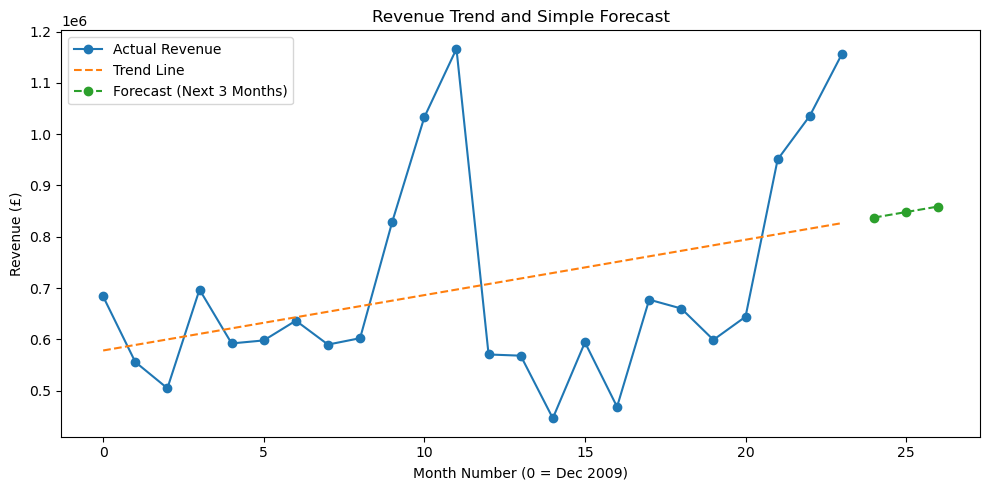

In [39]:
fig, ax = plt.subplots(figsize=(10, 5))

# 1. Actual revenue
ax.plot(
    monthly_revenue["MonthNumber"],
    monthly_revenue["Revenue"],
    marker="o",
    label="Actual Revenue"
)

# 2. Trend line
ax.plot(
    monthly_revenue["MonthNumber"],
    model.predict(X),
    linestyle="--",
    label="Trend Line"
)

# 3. Forecast
ax.plot(
    future_months["MonthNumber"],
    future_predictions,
    marker="o",
    linestyle="--",
    label="Forecast (Next 3 Months)"
)

# 4. Labels and title
ax.set_xlabel("Month Number (0 = Dec 2009)")
ax.set_ylabel("Revenue (£)")
ax.set_title("Revenue Trend and Simple Forecast")

# 5. Legend
ax.legend()

# 6. Adjust layout
fig.tight_layout()

# 7. Save the figure
fig.savefig(
    "../reports/figures/08_revenue_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

# 8. Display the figure
plt.show()

# 9. Close the figure
plt.close(fig)